In [ ]:
import os, sys
if '..' not in sys.path:
    sys.path.append('..')
    os.chdir('..')
    

import pandas as pd
import torch
import numpy as np

import src.inference as inf
from src.el_nino import read_enso_data

import matplotlib.pyplot as plt

import matplotlib.patches as patches
import seaborn as sns
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import pdist, squareform
import plotly.graph_objects as go

In [21]:
VALIDATION = True

config_file = "checkpoint/temperature_only/params-temperature-exp-2-c30.yaml"
read_path="results/temperature"


params, dataset = inf.read_data(config_file,validation=VALIDATION)

E, F = inf.get_model_results(read_path)

if VALIDATION:
    E_val, F_val = inf.get_model_results(read_path, validation=True)

tsne_E, tsne_prot, tsne_Eval = inf.get_TSNE(read_path, validation=VALIDATION)
umap_E, umap_prot, umap_Eval = inf.get_UMAP(read_path, validation=VALIDATION)

INFO:root:data loader created
Loaded E and F from results/temperature
Loaded E and F from results/temperature


In [22]:
cluster_prob, cluster_id = torch.max(F, dim=1) 
df = pd.DataFrame({"cluster_id": cluster_id.cpu(), "cluster_prob": cluster_prob.cpu(),
                   'sample_type':'train','date':dataset.time})

if VALIDATION:

    val_cluster_prob, val_cluster_id = torch.max(F_val, dim=1) # Obtém os valores máximos e seus índices
    df_val = pd.DataFrame({"cluster_id": val_cluster_id.cpu(),"cluster_prob": val_cluster_prob.cpu(),
                           'sample_type':'val','date':dataset.val_time})
        
    df =  pd.concat([df,df_val]).reset_index(drop=True) 
    df = df.sort_values('date')
    
    
    combined_dataset = torch.cat((dataset[:][0], dataset.validation_imgs))[df.index]
    tsne = np.concatenate((tsne_E, tsne_Eval))[df.index]

    df = df.reset_index(drop=True)  

else:
    combined_dataset = dataset[:][0]

In [23]:
# # # Plot the TSNE results
# plt.figure(figsize=(10, 10))

# cluster_labels = F.argmax(axis=1).cpu().numpy()
# plt.scatter(umap_E[:,0], umap_E[:,1], c= df_el_nino[df_el_nino['sample_type']=='train']['ONI'].values, cmap='coolwarm',  s=0.2,alpha=1)
# plt.scatter(umap_Eval[:,0], umap_Eval[:,1], c= df_el_nino[df_el_nino['sample_type']=='val']['ONI'].values, cmap='coolwarm', s=0.2,alpha=1)

# for i, (x, y) in enumerate(umap_prot):
#     plt.text(x, y, i, color='black', fontsize=12, ha='center', va='center')

# plt.title("UMAP of Latent Points and Prototypes")
# plt.show()


In [24]:
oni_index = read_enso_data()

df_el_nino = df.copy()
df_el_nino['date_period'] = df_el_nino['date'].dt.to_period('M')
df_el_nino = df_el_nino.merge(oni_index, left_on='date_period', right_index=True, how='left')

16.525424% dos pontos do Cluster 22 foram durante o El Niño

In [25]:
cluster_dist = pd.crosstab(df_el_nino['Label'], df_el_nino['cluster_id'],normalize='columns') * 100
cluster_dist

cluster_id,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
Label,,,,,,,,,,,,,,,,,,,,,
El Niño,6.141522,7.853403,16.825397,2.197802,3.985932,2.064516,4.372842,3.499327,3.280840,4.634994,...,6.666667,7.117438,16.525424,3.900709,5.909618,6.326034,3.914591,5.717762,4.830287,8.445040
La Niña,9.479306,9.816754,4.126984,6.907378,16.412661,13.548387,11.162255,10.363392,5.905512,8.806489,...,11.461988,15.539739,4.802260,17.257683,13.209733,12.895377,13.404508,16.545012,15.665796,8.847185
Neutro,84.379172,82.329843,79.047619,90.894819,79.601407,84.387097,84.464902,86.137281,90.813648,86.558517,...,81.871345,77.342823,78.672316,78.841608,80.880649,80.778589,82.680902,77.737226,79.503916,82.707775


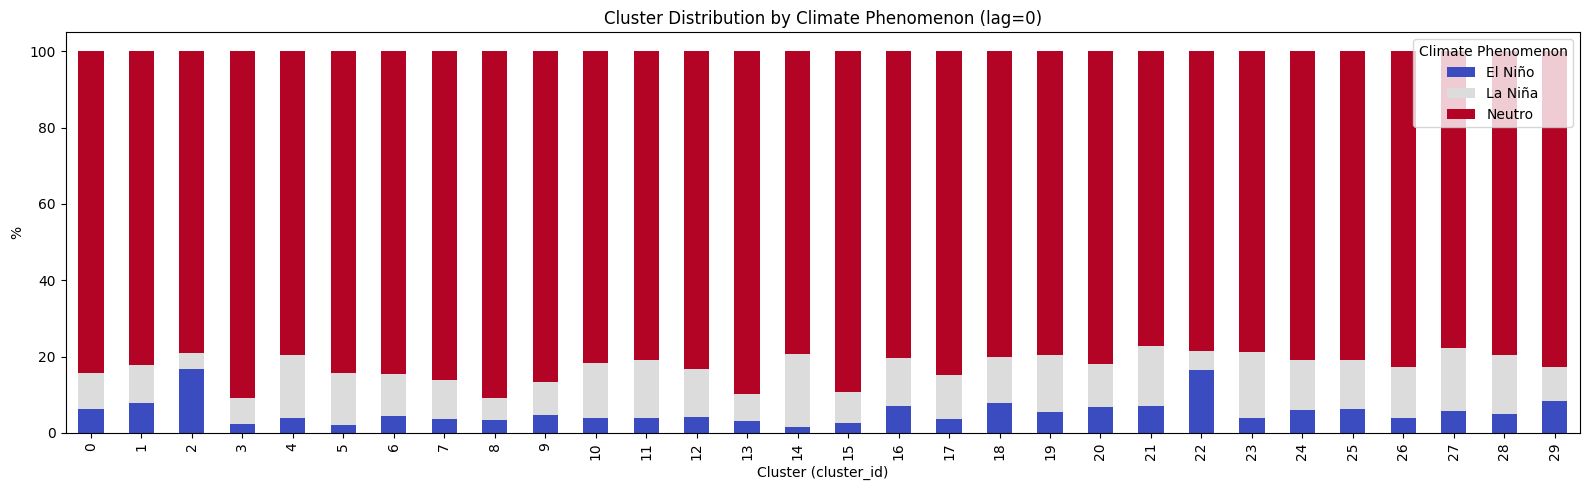

In [26]:
cluster_dist.T.plot(kind='bar', stacked=True, figsize=(16, 5), colormap='coolwarm')
plt.title('Cluster Distribution by Climate Phenomenon (lag=0)')
plt.xlabel('Cluster (cluster_id)')
plt.ylabel('%')
plt.legend(title='Climate Phenomenon')
plt.tight_layout()
plt.show()

"9.147772% dos dias do El Niño estão no Cluster 22"

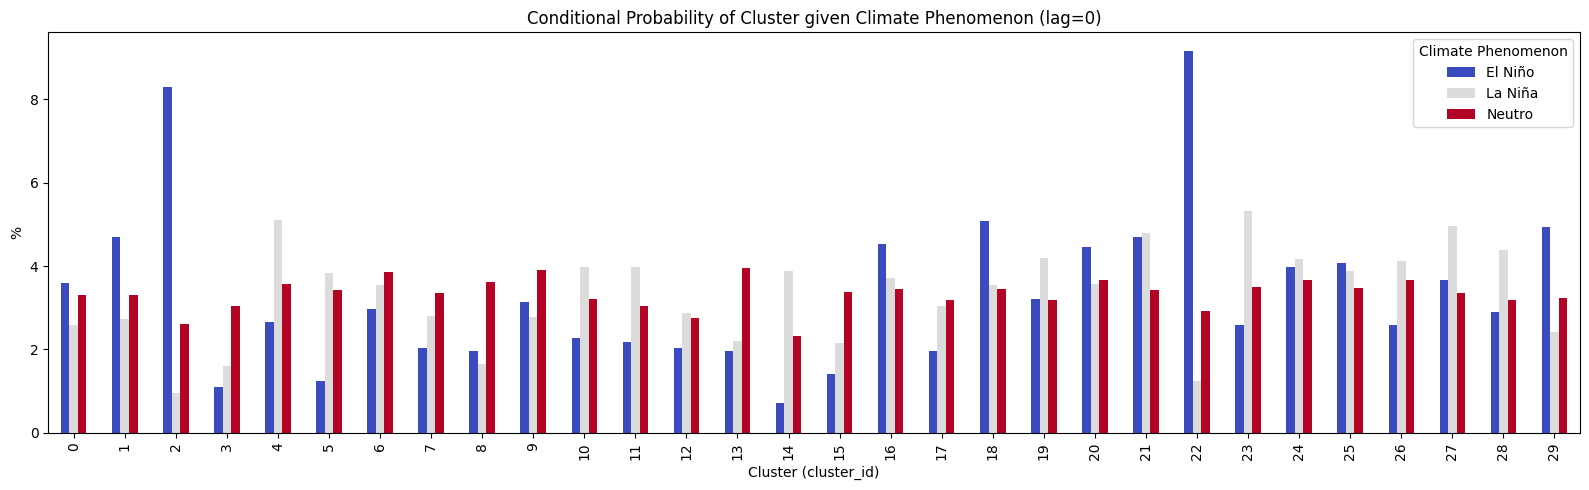

In [27]:
conditional_proba = pd.crosstab(df_el_nino['Label'], df_el_nino['cluster_id'],normalize='index') * 100

conditional_proba.T.plot(kind='bar', stacked=False, figsize=(16, 5), colormap='coolwarm')
plt.title('Conditional Probability of Cluster given Climate Phenomenon (lag=0)')
plt.xlabel('Cluster (cluster_id)')
plt.ylabel('%')
plt.legend(title='Climate Phenomenon')
plt.tight_layout()
plt.show()

Análise de Anomalia

Text(0.5, 1.0, 'Probability of Occurrence of Each Cluster')

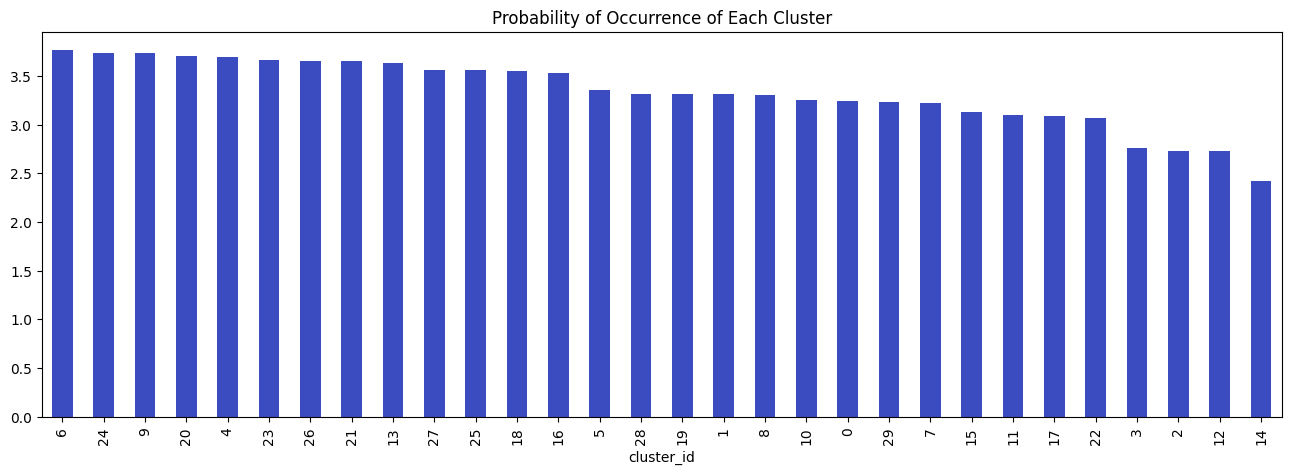

In [28]:
cluster_total_prob =df_el_nino['cluster_id'].value_counts(normalize=True)*100
cluster_total_prob.plot(kind='bar',figsize=(16, 5), colormap='coolwarm')
plt.title('Probability of Occurrence of Each Cluster')

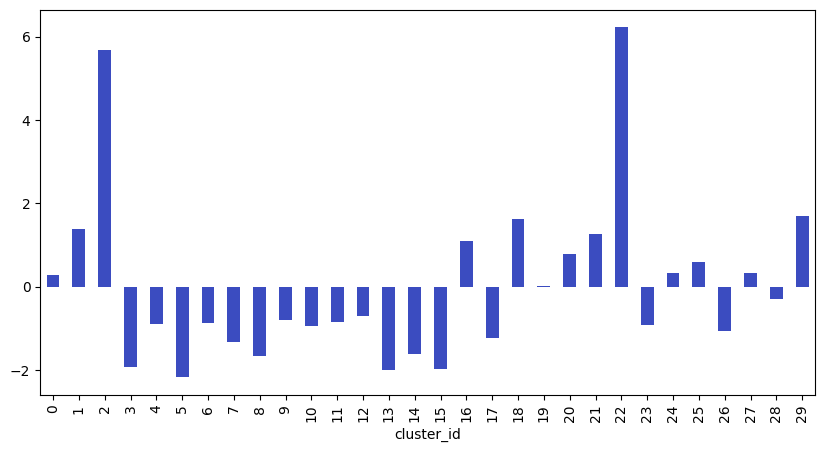

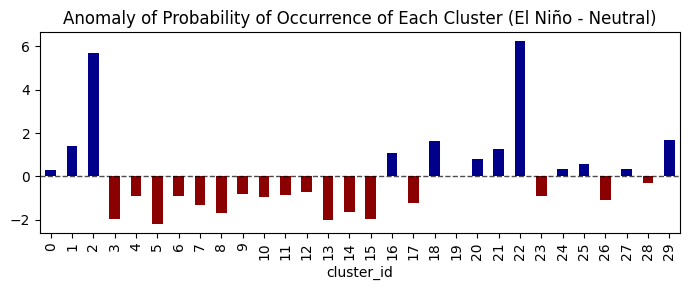

In [29]:
conditional_proba.loc["Anomaly"] = conditional_proba.loc["El Niño"]  - conditional_proba.loc["Neutro"] 
conditional_proba.loc['Anomaly'].plot(kind='bar',figsize=(10, 5), colormap='coolwarm')

# Re-plot with red for negative and blue for positive anomalies
vals = conditional_proba.loc['Anomaly']
colors = ['darkblue' if v >= 0 else 'darkred' if v < 0 else 'gray' for v in vals.values]
plt.figure(figsize=(7, 3))
vals.plot(kind='bar', color=colors)
plt.axhline(0, color='black', lw=1, linestyle='--', alpha=0.7)
plt.title('Anomaly of Probability of Occurrence of Each Cluster (El Niño - Neutral)')
plt.tight_layout()
plt.show()

> Encontrar um lag ótimo (quanto tempo depois o el nino afeta as distribuições desse local?)

> Validar com um teste estatístico

> Repetir só com os níveis de SST

> Repetir com modelo com mais dados (adicionar prep, etc?)

Anomalias de probabilidade vs lags:

In [30]:
import pandas as pd
df['date_period'] = df['date'].dt.to_period('M')

def get_anon(df):
    anomalias_list = {}

    # 2. Loop Otimizado
    for lag in range(-12, 13):

        df_el_nino = df.copy()
        df_el_nino = df_el_nino.merge(oni_index.shift(lag).dropna(), left_on='date_period', right_index=True, how='left')
        
        conditional_proba = pd.crosstab(df_el_nino['Label'], df_el_nino['cluster_id'],normalize='index') * 100
        # conditional_proba.loc["Anomaly"] = 
        
        anomalias_list[lag] = conditional_proba.loc["El Niño"]  - conditional_proba.loc["Neutro"] 

    # 4. Concatenação Final
    anom = pd.DataFrame(anomalias_list).sort_index(axis=1)
    anom.columns.name = 'Lag'
    return anom

anom = get_anon(df)

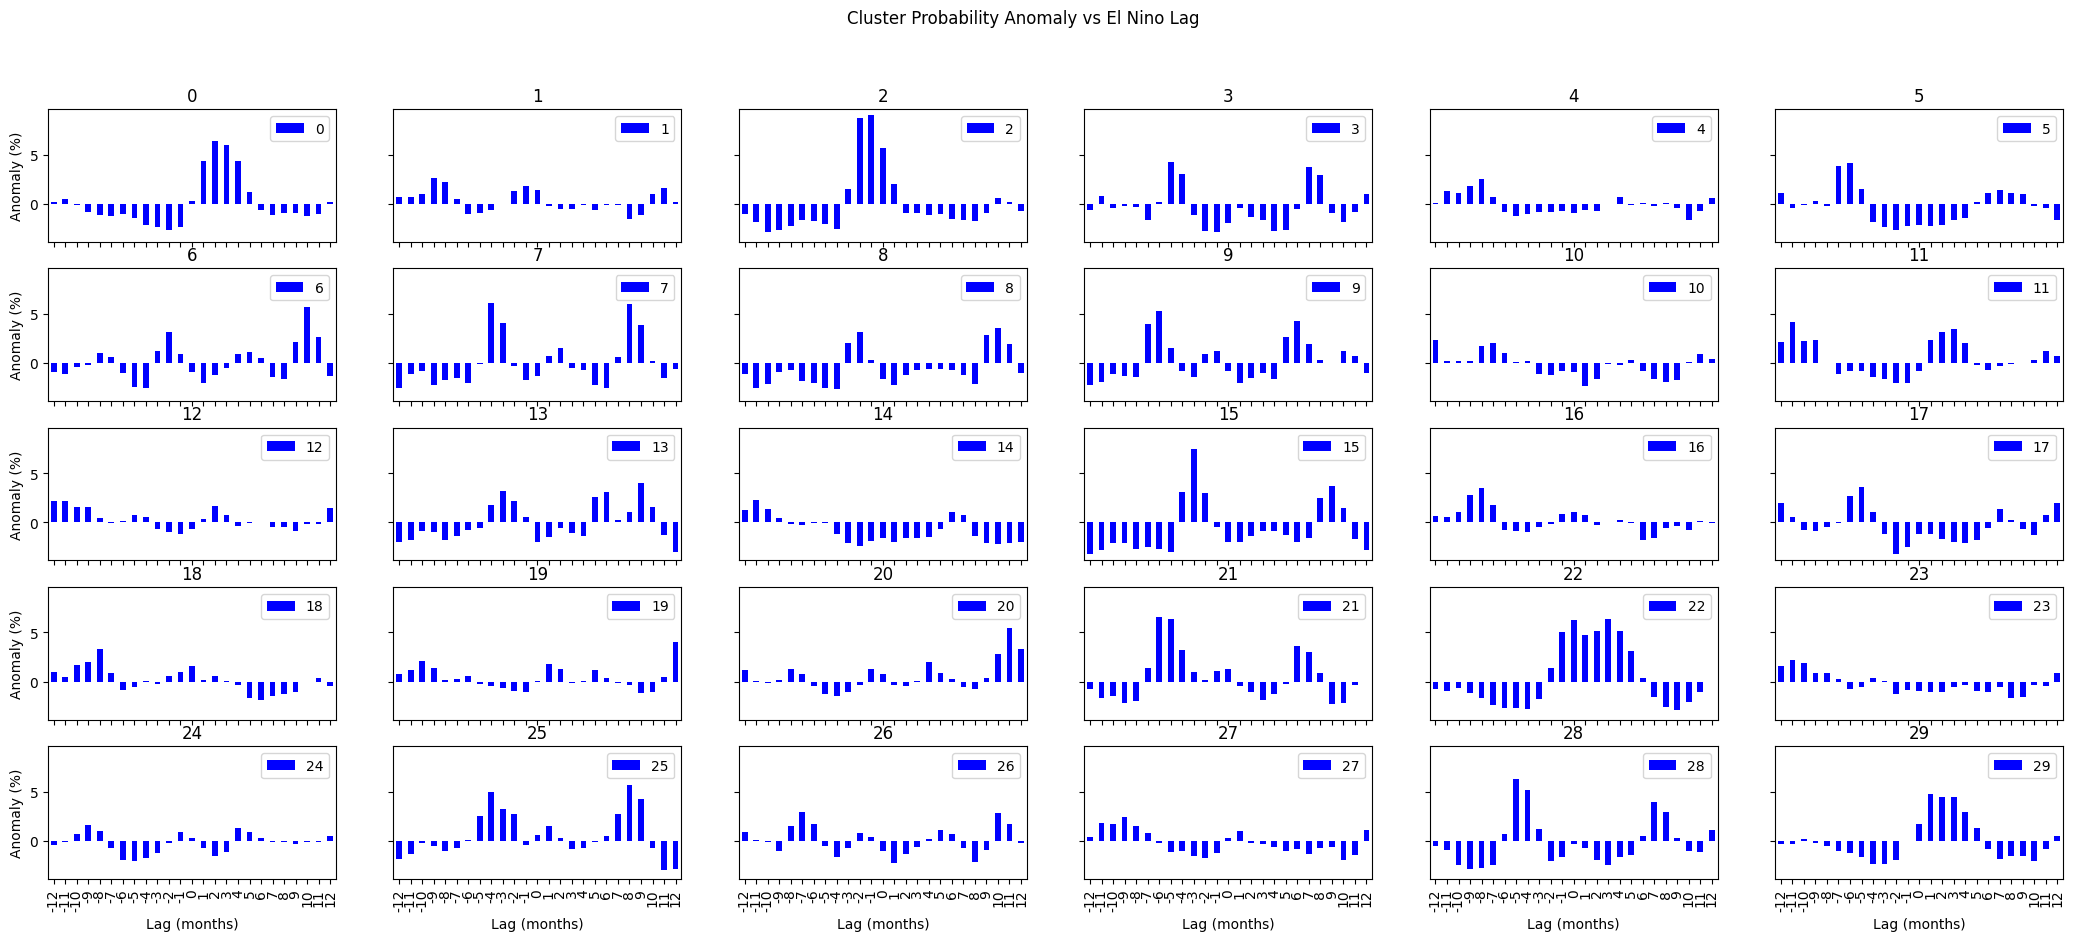

In [31]:
_ = anom.T.plot.bar(
    subplots=True,
    layout=(5, 6),
    figsize=(26, 10),
    color='blue',
    # colormap='coolwarm',
    sharex=True,
    sharey=True,
    title='Cluster Probability Anomaly vs El Nino Lag',
    ylabel='Anomaly (%)',
    xlabel='Lag (months)'

)

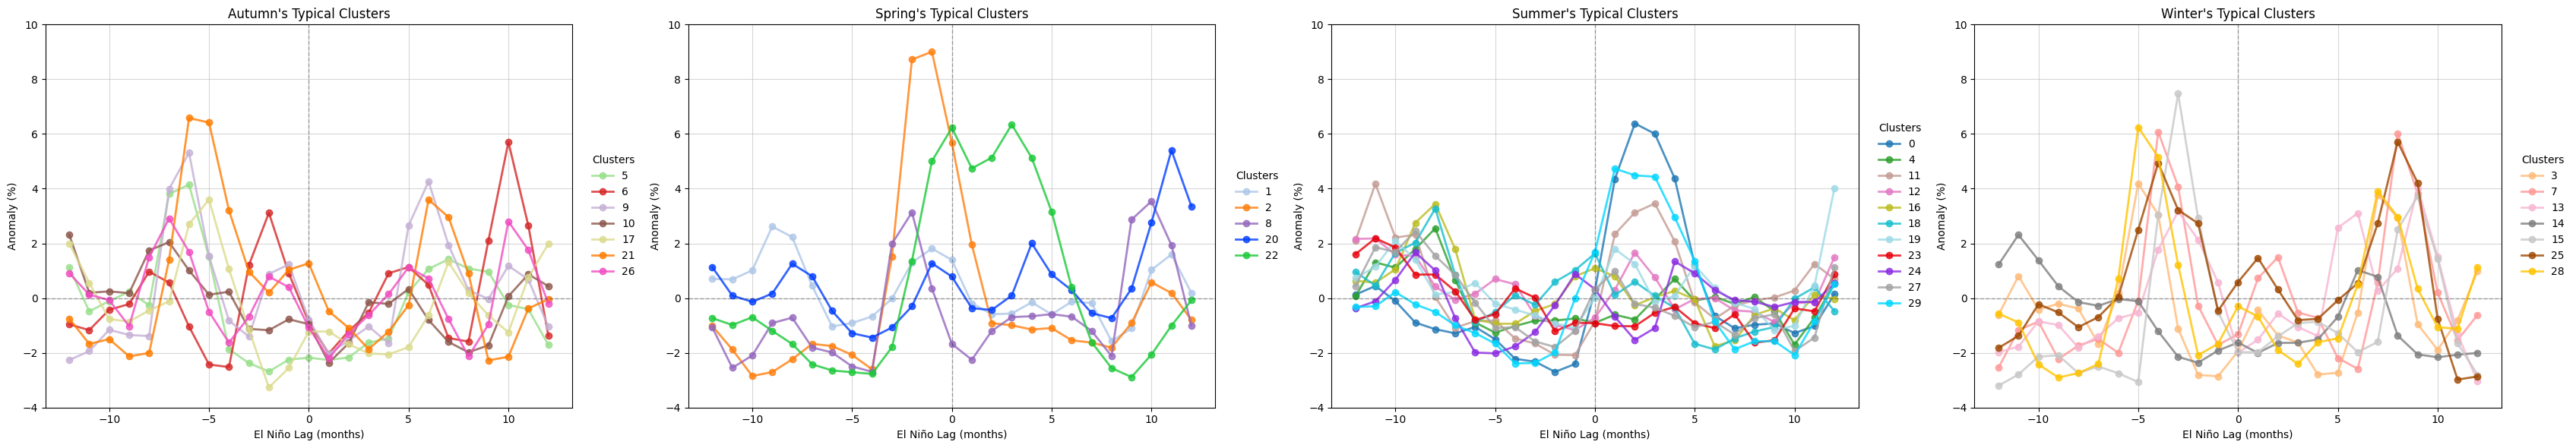

In [42]:
grupos_map_season = {'Autumn': [5, 6, 9, 10, 17, 21, 26],
 'Spring': [1, 2, 8, 20, 22],
 'Summer': [0, 4, 11, 12, 16, 18, 19, 23, 24, 27, 29],
 'Winter': [3, 7, 13, 14, 15, 25, 28]}

pallete30 = sns.color_palette("tab20", 20) + sns.color_palette("bright", 10)

fig, axes = plt.subplots(1,4, figsize=(40, 6))
axes = axes.flatten()

for idx, (season, cur_clusters) in enumerate(grupos_map_season.items()):

    anom.T[cur_clusters].plot(
        marker='o',
        lw=2,
        alpha=0.8,
        ax=axes[idx],
        color=[pallete30[i] for i in cur_clusters],
    )
    # axes[idx].invert_xaxis()
    
    axes[idx].axhline(0, color='black', lw=1, linestyle='--', alpha=0.3)
    axes[idx].axvline(0, color='black', lw=1, linestyle='--',  alpha=0.3)
    axes[idx].grid(True, alpha=0.5)
    axes[idx].set_ylim(-4, 10)
        
    axes[idx].set_title(f"{season}'s Typical Clusters")
    axes[idx].set_ylabel('Anomaly (%)')
    axes[idx].set_xlabel('El Niño Lag (months)')

    axes[idx].legend(
            loc='center left',
            bbox_to_anchor=(1.02, 0.5),
            frameon=False,
            title="Clusters"
        )
    
# Make room for side legends
# fig.suptitle('Cluster Probability Anomaly vs El Nino Lag by Season', fontsize=16)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

In [14]:
# from scipy.stats import chi2_contingency

# anon_test = pd.DataFrame(index=range(-13,13), columns=['p_value','significant'])

# for lag in range(-13,13):
#     df_el_nino = df.copy()
#     df_el_nino['date_period'] = df_el_nino['date'].dt.to_period('M')
#     df_el_nino = df_el_nino.merge(oni_index.shift(lag).dropna(), left_on='date_period', right_index=True, how='left')

#     df_el_nino = df_el_nino[df_el_nino['Label'].isin(['El Niño','Neutro'])]


#     table = pd.crosstab(df_el_nino['Label'], df_el_nino['cluster_id'])

#     chi2, p_value, dof, expected = chi2_contingency(table)
    
#     anon_test.loc[lag,'p_value'] = p_value
#     anon_test.loc[lag,'significant'] = p_value < 0.05
    
#     residuals = (table - expected) / np.sqrt(expected)
# anon_test

-> Como testar se esse aumento é dado o el nino ou a epóca do ano?

Probabilidade do cluster tem que ser calculada pela época do ano!

Ideia 1: apenas separar por estação do ano

In [15]:
def get_season(date):
    month = date.month
    day = date.day

    # Verão: 21 ou 22 de dezembro a 20 ou 21 de março
    if (month == 12 and day >= 21) or \
       (month == 1 or month == 2) or \
       (month == 3 and day <= 20):
        return 'Summer'
    # Outono: 20 ou 21 de março a 20 ou 21 de junho
    elif (month == 3 and day >= 21) or \
         (month == 4 or month == 5) or \
         (month == 6 and day <= 20):
        return 'Autumn'
    # Inverno: 20 ou 21 de junho a 22 ou 23 de setembro
    elif (month == 6 and day >= 21) or \
         (month == 7 or month == 8) or \
         (month == 9 and day <= 22):
        return 'Winter'
    # Primavera: 22 ou 23 de setembro a 20 ou 21 de dezembro
    else: # (month == 9 and day >= 23) or (month == 10 or month == 11) or (month == 12 and day <= 20)
        return 'Spring'

# Aplique a função para criar uma nova coluna 'season'
df['season'] = df['date'].apply(get_season)
df.head(2)

,cluster_id,cluster_prob,sample_type,date,date_period,season
0,19,0.885574,train,1961-01-01,1961-01,Summer
1,27,0.890362,train,1961-01-02,1961-01,Summer


1. Spring  (estação em que o El nino é mais frequente)

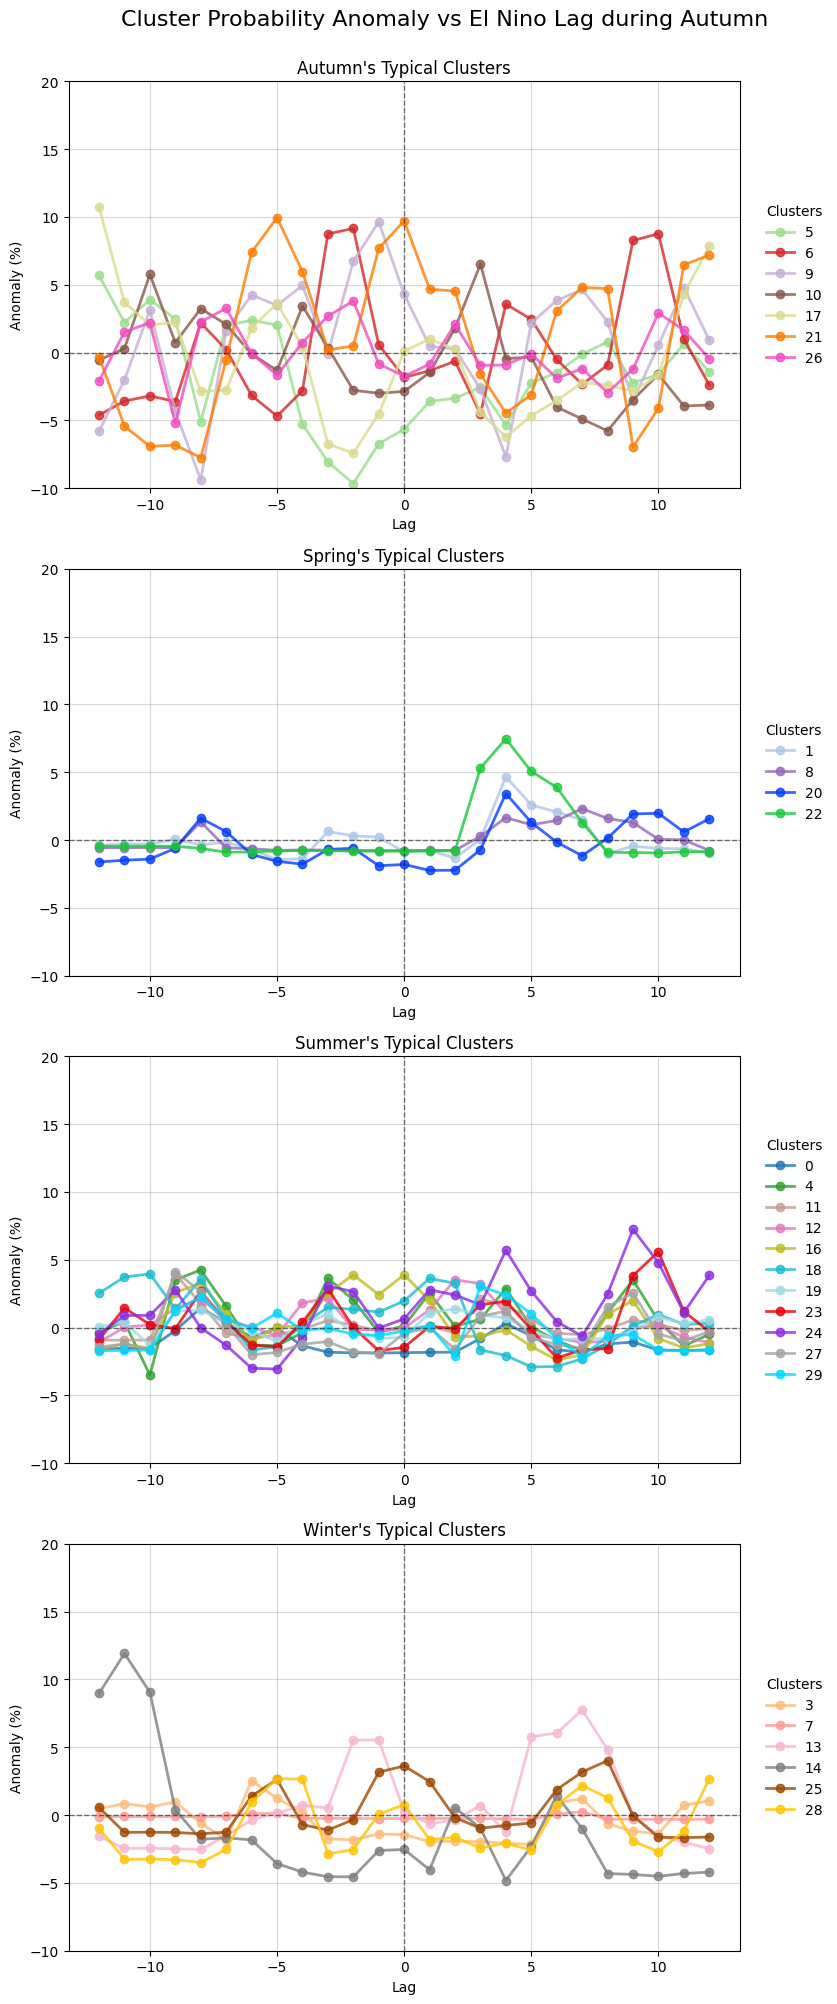

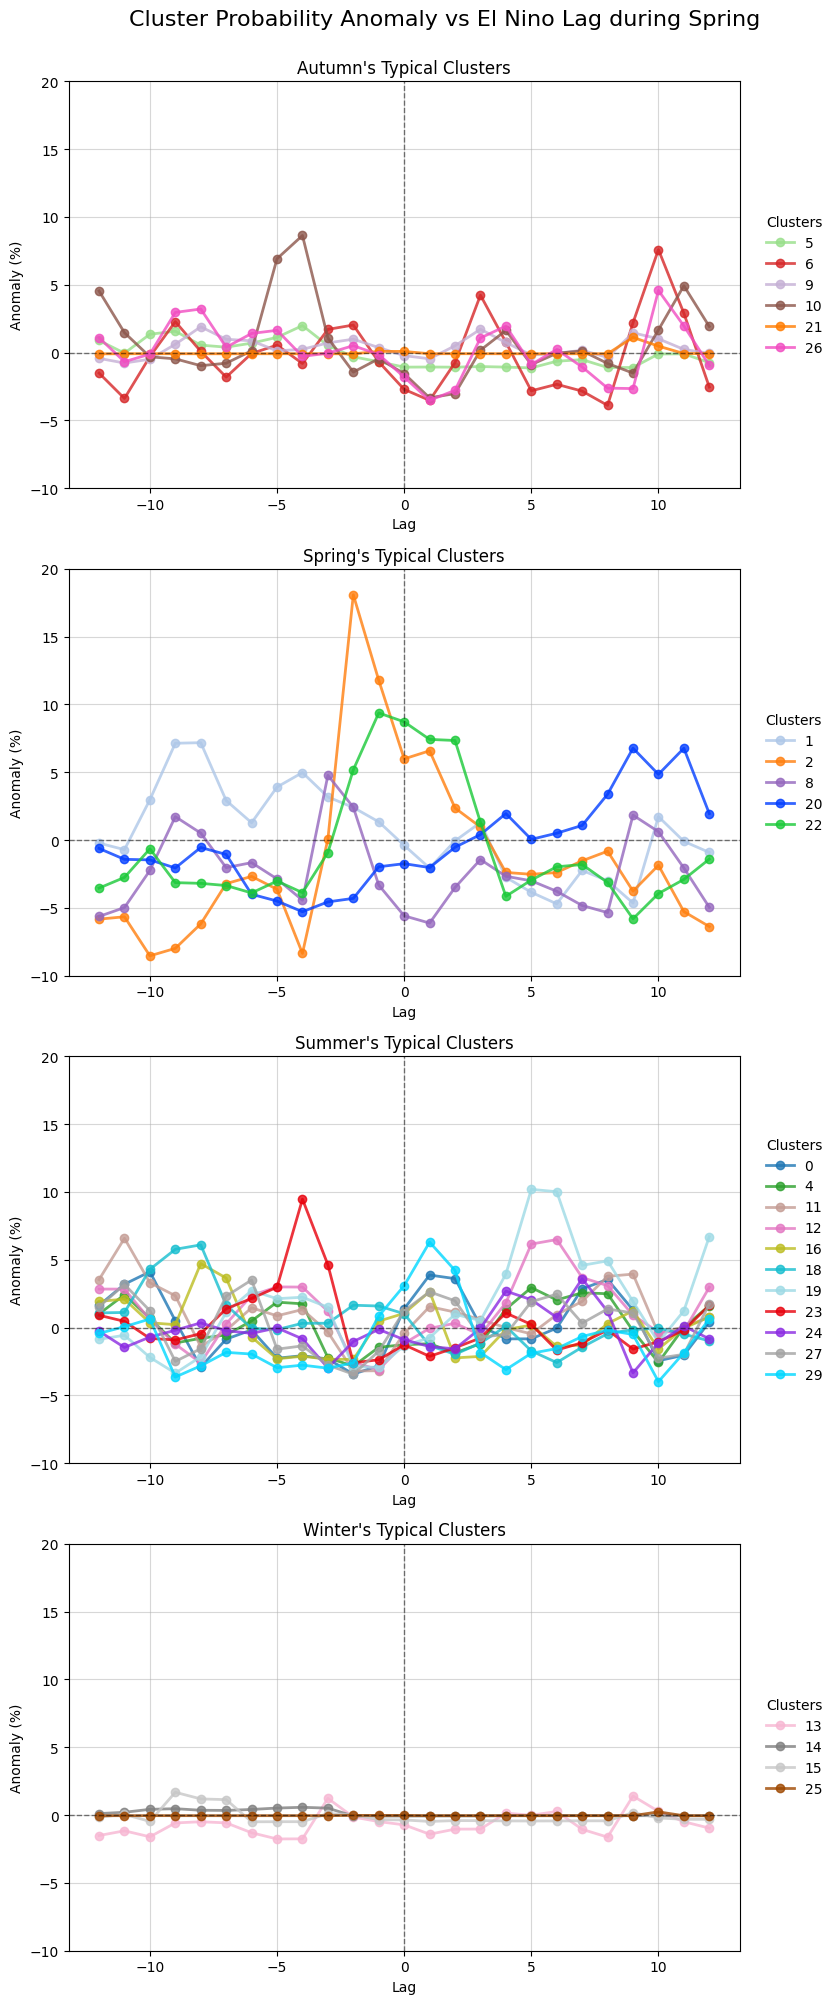

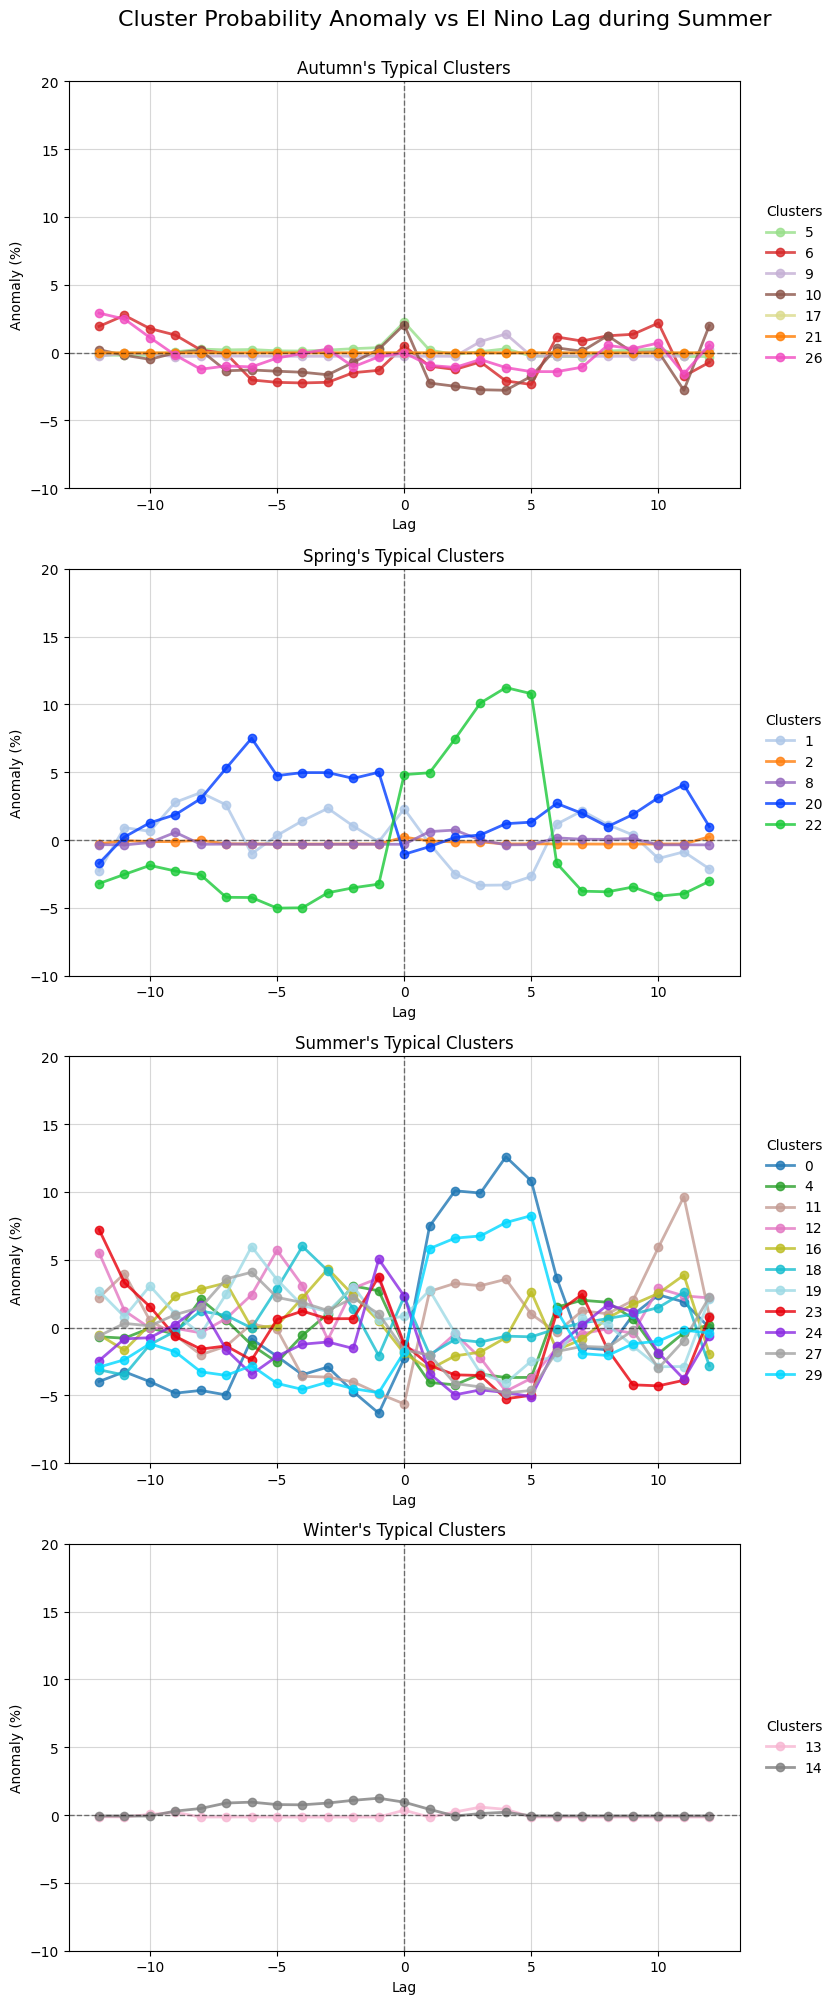

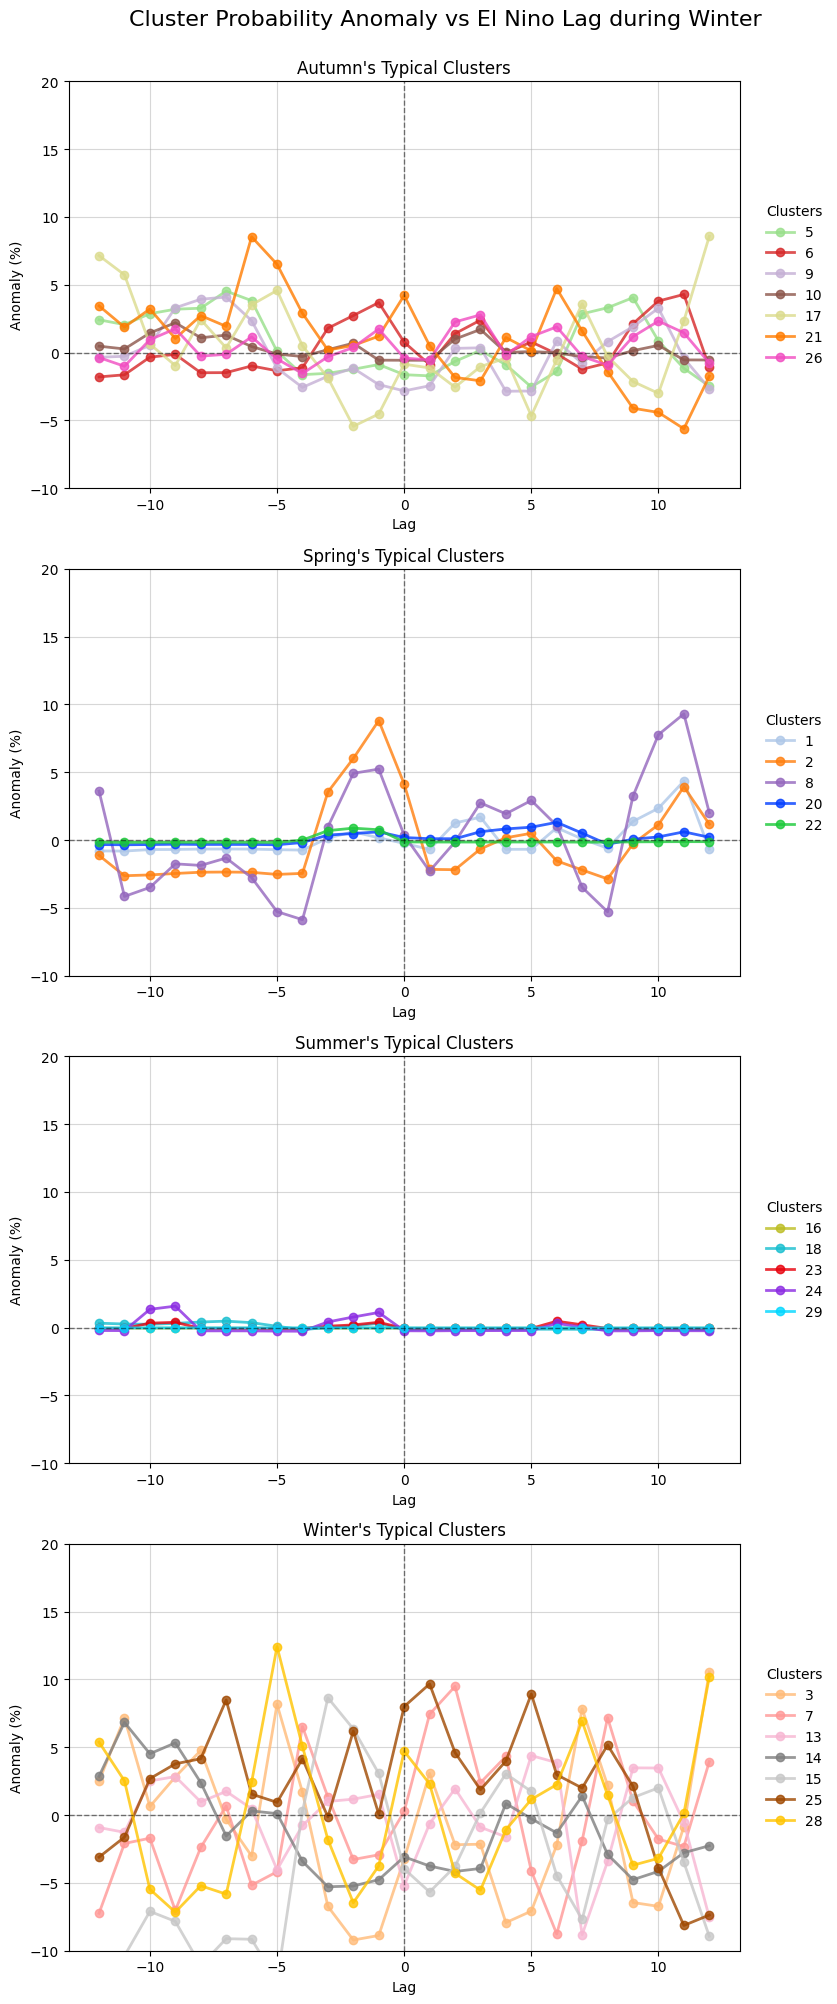

In [16]:
grupos_map_season = {'Autumn': [5, 6, 9, 10, 17, 21, 26],
                    'Spring': [1, 2, 8, 20, 22],
                    'Summer': [0, 4, 11, 12, 16, 18, 19, 23, 24, 27, 29],
                    'Winter': [3, 7, 13, 14, 15, 25, 28]}

pallete30 = sns.color_palette("tab20", 20) + sns.color_palette("bright", 10)



for cur_season in grupos_map_season.keys():
    
    fig, axes = plt.subplots(4,1, figsize=(10,20))
    anom_season = get_anon(df[df['season']==cur_season])
 
    for idx, (season, cur_clusters) in enumerate(grupos_map_season.items()):

        available_clusters = [c for c in cur_clusters if c in anom_season.index]
        anom_season.T[available_clusters].plot(
            marker='o',
            lw=2,
            alpha=0.8,
            ax=axes[idx],
            color=[pallete30[i] for i in available_clusters],
        )
        
        axes[idx].axhline(0, color='black', lw=1, linestyle='--', alpha=0.5)
        axes[idx].axvline(0, color='black', lw=1, linestyle='--',  alpha=0.5)
        axes[idx].grid(True, alpha=0.5)
        axes[idx].set_ylim(-10, 20)
            
        axes[idx].set_title(f"{season}'s Typical Clusters")
        axes[idx].set_ylabel('Anomaly (%)')

        axes[idx].legend(
                loc='center left',
                bbox_to_anchor=(1.02, 0.5),
                frameon=False,
                title="Clusters"
            )

    # Make room for side legends
    fig.suptitle(f'Cluster Probability Anomaly vs El Nino Lag during {cur_season}', y=1, x=0.45, fontsize=16)
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()
    

In [17]:
# import pandas as pd
# from statsmodels.stats.proportion import proportions_ztest
# from statsmodels.stats.multitest import multipletests

# # Exemplo de dados: Contagens de dias em que o Cluster X apareceu
# # Nobs = número total de dias analisados em cada fase (El Niño vs Neutro)
# # Count = número de dias que o Cluster X apareceu
# lag= 0
# df_el_nino = df[df['season']=='Autumn'].copy()
# df_el_nino = df_el_nino.merge(oni_index.shift(lag).dropna(), left_on='date_period', right_index=True, how='left')

# contagens =  pd.crosstab(df_el_nino['Label'], df_el_nino['cluster_id']).drop('La Niña')
# resultados = []

# # Supondo que 'n_dias_elnino' e 'n_dias_neutro' são o total de dias em cada fase na estação
# total_elnino = contagens.sum(axis=1).loc['El Niño']
# total_neutro = contagens.sum(axis=1).loc['Neutro']

# # Loop pelos seus 30 clusters
# for cluster in range(30):
#     # Exemplo: O cluster 0 apareceu 50 vezes no El Niño e 40 no Neutro
#     count_elnino = contagens.loc['El Niño', cluster] if cluster in contagens.columns else 0
#     count_neutro = contagens.loc['Neutro', cluster] if cluster in contagens.columns else 0
    
#     # Teste Z
#     stat, p_value = proportions_ztest([count_elnino, count_neutro], 
#                                       [total_elnino, total_neutro])
    
#     resultados.append({'cluster': cluster, 'p_value': p_value})

# df_res = pd.DataFrame(resultados)

# # Aplica correção de Benjamini-Hochberg (FDR)
# reject, pvals_corrected, _, _ = multipletests(df_res['p_value'], alpha=0.05, method='fdr_bh')

# df_res['significativo'] = reject
# df_res['p_valor_corrigido'] = pvals_corrected

# # Mostra apenas os que realmente são anomalias estatísticas
# print(df_res[df_res['significativo'] == True])

## Trajetória

> Qual o impacto do el nino nas trajetória (semanal, mensal) dos padrões climáticos?

1. Probabilidades de transição (markov)

In [18]:
lag = 0
df_el_nino = df.copy()
df_el_nino = df_el_nino.merge(oni_index.shift(lag).dropna(), left_on='date_period', right_index=True, how='left')
df_el_nino['cluster_next'] = df_el_nino['cluster_id'].shift(-1)

# 2. Cálculo das Probabilidades de Transição
transicoes = {}

# Agrupamos por Estação e Status do ENSO
groups = df_el_nino.dropna(subset=['cluster_next']).groupby(['season', 'Label'])


for (estacao, status), group_df in groups:
    # Cria a matriz de transição: Linhas (Origem) -> Colunas (Destino)
    # normalize='index' garante que a soma das linhas seja 100% (Probabilidade)
    matriz = pd.crosstab(
        group_df['cluster_id'], 
        group_df['cluster_next'], 
        normalize='index'
    ) * 100
    
    transicoes[(estacao, status)] = matriz

In [19]:
transicoes[("Summer", "El Niño")][22].to_frame('El Nino').join(transicoes[("Summer", "Neutro")][22].to_frame('Neutro'))

,El Nino,Neutro
cluster_id,,
0,0.000000,1.358696
1,21.428571,12.903226
2,100.000000,30.769231
4,0.000000,0.253807
5,0.000000,0.000000
6,0.000000,0.000000
10,0.000000,0.000000
11,0.000000,0.000000
12,0.000000,0.000000


2. LSTM/GRU

In [20]:
#define a distribuição mensal dos clusters 
monthly_dist = pd.crosstab(df_el_nino["date_period"], df_el_nino["cluster_id"],normalize='index')
monthly_dist.head(2)

cluster_id,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
date_period,,,,,,,,,,,,,,,,,,,,,
1961-01,0.0,0.0,0.0,0.0,0.032258,0.0,0.064516,0.0,0.0,0.0,...,0.0,0.0,0.0,0.129032,0.000000,0.0,0.032258,0.129032,0.0,0.0
1961-02,0.0,0.0,0.0,0.0,0.107143,0.0,0.142857,0.0,0.0,0.0,...,0.0,0.0,0.0,0.214286,0.071429,0.0,0.035714,0.035714,0.0,0.0


A distribuição mensal dá, de fato, um sinal importante para o El Nino?

In [21]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# 2. Engenharia de Features (Windowing)
def create_lagged_features(data, window_size=6):
    """
    Cria features achatando os últimos N meses.
    Ex: Se window=6 e temos 30 clusters, teremos 180 colunas (t-1_c1... t-6_c30)
    """
    df_list = []
    for lag in range(1, window_size + 1):
        shifted = data.shift(lag)
        shifted.columns = [f'lag_{lag}_cluster_{c}' for c in shifted.columns]
        df_list.append(shifted)
    
    return pd.concat(df_list, axis=1)

# Escolha sua janela (6 ou 12 meses)
WINDOW = 12
X = create_lagged_features(monthly_dist, window_size=WINDOW).dropna(axis=0)

# 3. Preparar o Target (Alvo)
# Supondo que 'oni_index' tem o índice mensal e definimos El Niño como > 0.5
# Alinhar o target com as features (o target é o mês ATUAL, as features são o PASSADO)
y = (df_el_nino.drop_duplicates(['date_period','Label']).set_index('date_period')['Label'] == 'El Niño').astype(int) # 1 = El Niño, 0 = Não El Niño

# Alinhar índices (remover NaNs gerados pelo shift)
common_index = X.index.intersection(y.index)
X = X.loc[common_index].dropna()
y = y.loc[X.index] # Garante mesmo tamanho

# 4. Validação (TimeSeriesSplit é mandatório aqui, não use Shuffle!)
tscv = TimeSeriesSplit(n_splits=7)
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

scores = cross_val_score(model, X, y, cv=tscv, scoring='roc_auc')
scores = scores[~np.isnan(scores)]

print(f"ROC-AUC Médio: {scores.mean():.2f}")
print(f"Desvio Padrão: {scores.std():.2f}")

# Treino final para ver importância
model.fit(X, y)

# Quais lags/clusters são melhores preditores?
importances = pd.Series(model.feature_importances_, index=X.columns)
print("\nTop 5 Preditores (Lag X - Cluster Y):")
print(importances.sort_values(ascending=False).head(5))

ROC-AUC Médio: 0.78
Desvio Padrão: 0.18

Top 5 Preditores (Lag X - Cluster Y):
lag_9_cluster_1      0.026241
lag_3_cluster_15     0.023728
lag_1_cluster_2      0.023053
lag_6_cluster_21     0.020572
lag_11_cluster_23    0.018641
dtype: float64


In [22]:
for i, s in enumerate(scores):
    print(f"Fold {i}: AUC = {s:.3f}")

Fold 0: AUC = 0.517
Fold 1: AUC = 0.620
Fold 2: AUC = 0.588
Fold 3: AUC = 0.922
Fold 4: AUC = 0.945
Fold 5: AUC = 0.888
Fold 6: AUC = 0.978


yes. Climate patterns give strong El niño signal.
> This test did not considered the season

In [23]:
def add_seasonality_features(X):
    month = X.index.month
    X = X.copy()
    X['month_sin'] = np.sin(2 * np.pi * month / 12)
    X['month_cos'] = np.cos(2 * np.pi * month / 12)
    return X

X_season = add_seasonality_features(X)
scores = cross_val_score(
    model, X_season, y, cv=tscv, scoring='roc_auc'
)
scores = scores[~np.isnan(scores)]

print(f"ROC-AUC Médio: {scores.mean():.2f}")
print(f"Desvio Padrão: {scores.std():.2f}")


ROC-AUC Médio: 0.79
Desvio Padrão: 0.20


In [24]:
X_month = X_season[['month_sin', 'month_cos']]

scores_month = cross_val_score(
    model, X_month, y, cv=tscv, scoring='roc_auc'
)
scores = scores[~np.isnan(scores)]


print("AUC só sazonalidade:", np.nanmean(scores_month))

AUC só sazonalidade: 0.7327464276701836


In [25]:
seasons = X.index.month % 12 // 3  # 0=DJF,1=MAM,2=JJA,3=SON

for s in range(4):
    idx = seasons == s
    if idx.sum() > 30:
        scores = cross_val_score(
            model, X.loc[idx], y.loc[idx],
            cv=TimeSeriesSplit(n_splits=3),
            scoring='roc_auc'
        )
        print(f"Estação {s}: AUC = {np.nanmean(scores):.2f}")


Estação 0: AUC = 0.94
Estação 1: AUC = 0.79


/home/livia/Documentos/Projetos/climate-clustering/.venv/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/livia/Documentos/Projetos/climate-clustering/.venv/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/livia/Documentos/Projetos/climate-clustering/.venv/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Estação 2: AUC = 0.65
Estação 3: AUC = 0.75


/home/livia/Documentos/Projetos/climate-clustering/.venv/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


2. Does ENSO shift the monthly distribution (relative to what would be expected for that month)?

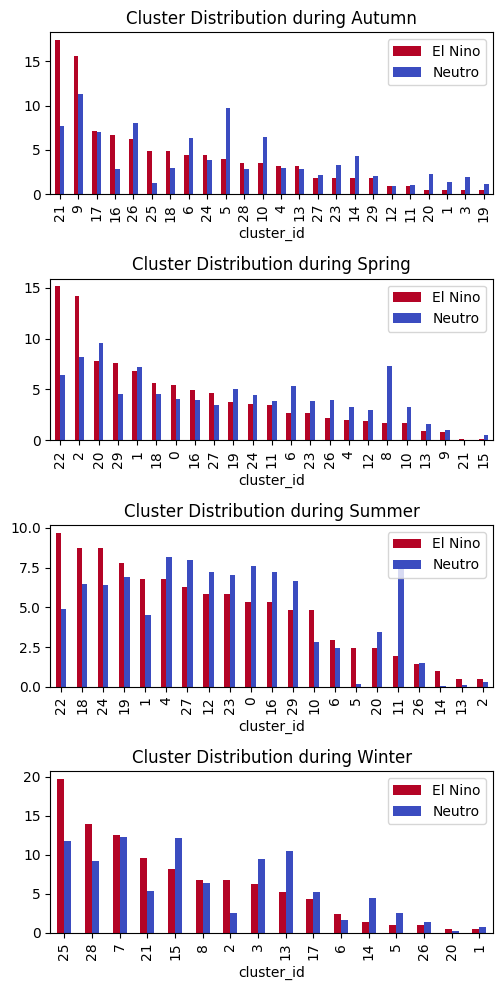

In [26]:
#typical summer 
cur_season = 'Summer'
fig, axs = plt.subplots(4,1, figsize=(5,10))
for cur_season in grupos_map_season.keys():

    neutral_summer = df_el_nino[(df_el_nino['season']==cur_season) & (df_el_nino['Label']=='Neutro')]
    neutral_summer = neutral_summer["cluster_id"].value_counts(normalize=True)*100

    elnino_summer = df_el_nino[(df_el_nino['season']==cur_season) & (df_el_nino['Label']=='El Niño')]
    elnino_summer = elnino_summer["cluster_id"].value_counts(normalize=True)*100

    elnino_summer.to_frame('El Nino').join(neutral_summer.to_frame('Neutro'))\
        .plot.bar(ax=axs[list(grupos_map_season.keys()).index(cur_season)], colormap='coolwarm_r',title=f'Cluster Distribution during {cur_season}')
        
plt.tight_layout()

In [27]:
vars_names = params['data']['surf_vars']
var_stats = {}
for var in range(len(vars_names)):
    vmin, vmax = combined_dataset[:,var,:,:].min(), combined_dataset[:,var,:,:].max()
    var_stats[var] = (vmin, vmax)
    
global_min, global_max = min(var_stats[0][0], var_stats[1][0]), max(var_stats[0][1], var_stats[1][1])

0 20
1 20
2 2
3 1
4 20
5 20
6 20


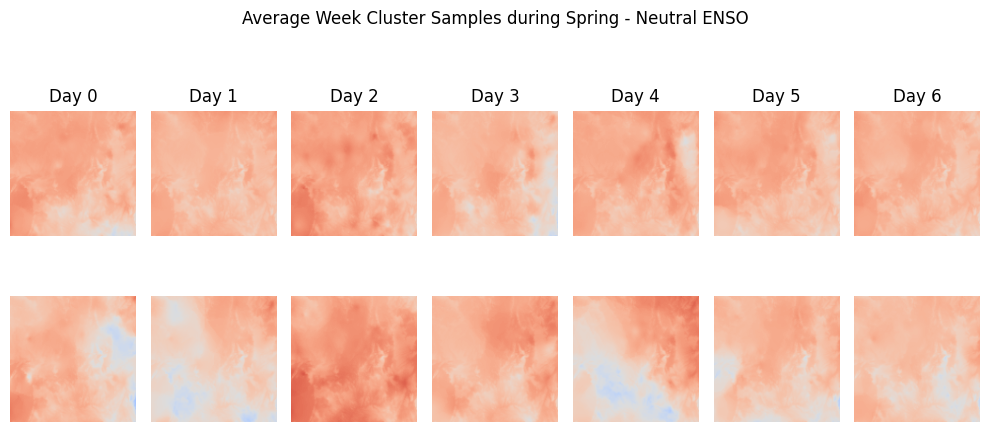

0 22
1 2
2 22
3 2
4 22
5 20
6 2


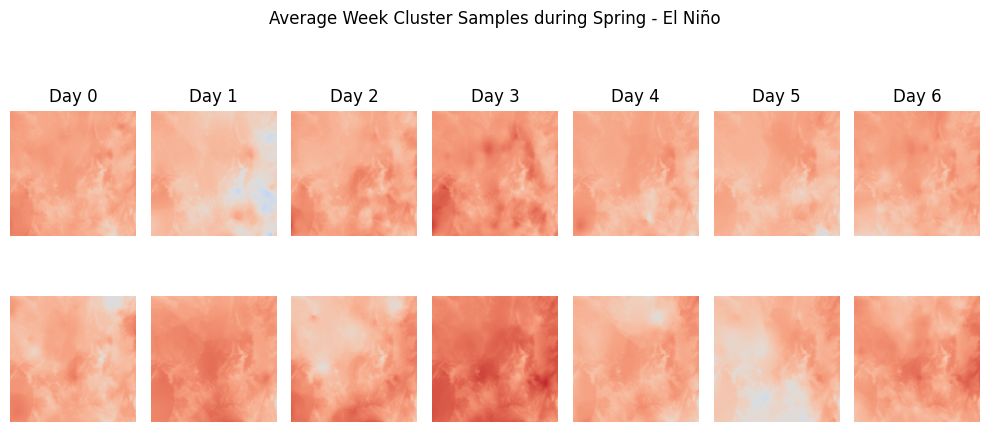

In [28]:
#average week in neutral summer 
cur_season = 'Spring'
df_el_nino = df.copy()
df_el_nino = df_el_nino.merge(oni_index.shift(lag).dropna(), left_on='date_period', right_index=True, how='left')

df_season = df_el_nino[(df_el_nino['season']==cur_season)]

df_neutral = df_season[df_season['Label'] == 'Neutro']
df_el_nino = df_season[df_season['Label'] == 'El Niño']

# Function to compute average week probabilities
def weekly_cluster_probabilities(df_sub):
    df_sub = df_sub.copy()
    df_sub['weekday'] = df_sub['date'].dt.weekday
    prob_table = df_sub.groupby('weekday')['cluster_id'].value_counts(normalize=True).unstack(fill_value=0)
    return prob_table

p_neutral_week = weekly_cluster_probabilities(df_neutral)
p_el_nino_week = weekly_cluster_probabilities(df_el_nino)


fig, ax = plt.subplots(2,7, figsize=(10,5))
average_week = p_neutral_week.idxmax(axis=1)
for day, cluster in average_week.items():
    print(day, cluster)
    random_index = np.random.choice(df[df['cluster_id']==cluster].index,size=1)[0]
    random_samples = combined_dataset[random_index]
    
    ax[0,day].imshow(random_samples[0],cmap='coolwarm',vmin=global_min, vmax=global_max)
    ax[1,day].imshow(random_samples[1],cmap='coolwarm',vmin=global_min, vmax=global_max)

    ax[0,day].set_title(f'Day {day}')
    
    if day ==0:
        ax[1,day].set_ylabel('tmin')
        ax[1,day].set_ylabel('tmax')
        
    ax[0,day].axis("off")
    ax[1,day].axis("off")
    
fig.suptitle(f'Average Week Cluster Samples during {cur_season} - Neutral ENSO')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(2,7, figsize=(10,5))

average_week = p_el_nino_week.idxmax(axis=1)
for day, cluster in average_week.items():
    print(day, cluster)
    random_index = np.random.choice(df[df['cluster_id']==cluster].index,size=1)[0]
    random_samples = combined_dataset[random_index]
    
    ax[0,day].imshow(random_samples[0],cmap='coolwarm',vmin=global_min, vmax=global_max)
    ax[1,day].imshow(random_samples[1],cmap='coolwarm',vmin=global_min, vmax=global_max)

    ax[0,day].set_title(f'Day {day}')
    
    if day ==0:
        ax[1,day].set_ylabel('tmin')
        ax[1,day].set_ylabel('tmax')
        
    ax[0,day].axis("off")
    ax[1,day].axis("off")
    
fig.suptitle(f'Average Week Cluster Samples during {cur_season} - El Niño')
plt.tight_layout()
plt.show()

In [29]:
climatology = (
    monthly_dist
    .groupby(monthly_dist.index.month)
    .mean()
)

anomalies = monthly_dist.copy()
for m in range(1, 13):
    anomalies.loc[anomalies.index.month == m] -= climatology.loc[m]
    
anomalies = anomalies.join(oni_index[['Label']])
anomalies['Label'] = (anomalies['Label']=='El Niño').astype(int)
anomalies.tail()

,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,Label
date_period,,,,,,,,,,,,,,,,,,,,,
2023-11,-0.048677,0.018519,0.266138,0.0,-0.050265,-0.011111,-0.022222,0.0,-0.014815,-0.004233,...,-0.000529,0.486243,-0.052910,-0.060317,-0.000529,-0.036508,-0.041270,0.0,-0.004233,1
2023-12,0.008705,-0.013313,0.146953,0.0,-0.054275,-0.003072,-0.014849,0.0,-0.002560,-0.001024,...,0.000000,0.462878,-0.059908,-0.032770,0.000000,-0.014337,-0.089606,0.0,0.053763,1
2024-01,0.206653,-0.057964,-0.004032,0.0,-0.074093,-0.001512,-0.025202,0.0,-0.003024,-0.003024,...,0.000000,0.152722,-0.065524,-0.057964,0.000000,-0.016633,-0.080645,0.0,0.298891,0
2024-02,0.182997,-0.002655,-0.001674,0.0,-0.030865,-0.001116,-0.022783,0.0,-0.001674,0.000000,...,-0.000558,0.196236,-0.081839,-0.069793,0.000000,-0.014470,-0.082050,0.0,0.139490,0
2024-03,0.025353,-0.038810,0.000000,0.0,-0.096270,-0.005040,-0.040827,0.0,-0.008065,-0.004032,...,0.000000,0.655292,-0.073589,-0.077621,0.000000,-0.017641,-0.090222,0.0,0.126815,0


In [30]:
from sklearn.linear_model import LinearRegression

results = {}

for cluster in anomalies.columns[:-1]:
    y = anomalies[cluster]
    X = anomalies['Label'].values.reshape(-1,1)
    reg = LinearRegression().fit(X, y)
    results[cluster] = reg.coef_[0]

In [31]:
anomalies.columns[:-1]

Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29],
      dtype='object')